In [41]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import random
import torch
import os
import numpy as np
import json
from model1 import CNN_3D,NiiDataset,MultiModalTransformer,NeuralNet,TransEModel,KGMultiModalTransformer
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

In [42]:
path_existence = []
data_prodromal=[]
data_swedd=[]
data_control=[]
data_PD = []
count_control = 0
count_PD = 0
count_swedd = 0
count_prodromal = 0
with open('PD1.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'E:/code/PPMI/PD/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_PD=count_PD+1
            data_PD.append(row)
            
with open('control.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'E:/code/PPMI/Control/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_control=count_control+1
            data_control.append(row)
            
with open('swedd.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'E:/code/PPMI/SWEDD/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_swedd=count_swedd+1
            data_swedd.append(row)

with open('prodromal.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'E:/code/PPMI/Prodromal/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_prodromal=count_prodromal+1
            data_prodromal.append(row)
print(count_PD) 
print(count_control) 
print(count_swedd) 
print(count_prodromal)

125
132
72
80


In [43]:
import numpy as np
import math
import torch

replace_dict = {
    'F': '0', 'M':'1', 'Normal':'0', 'Slight':'1', 'Mild':'2', 'Moderate':'3', 'Severe':'4',
    'T1-anatomical':'1', 'Processed':'1', 'BL':'0', 'V04':'1', 'V06':'2', 'V08':'4', 'V10':'5',
    'NiFTI':'1', '': '0', 'No':'0', 'Yes':'1', 'Stage 1':'1', 'Stage 2':'2', 'Stage 3':'3', 'Stage 4':'4',
    'On':'1', 'Off':'0', 'Stage 0':'0'
}

ehr_cols = [4, 5, 82, 83]
phe_cols = list(range(12, 45)) + [78, 79, 80, 84]

def preprocess_data(data, replace_dict, target_cols):
    processed_data = []
    for row in data:
        extracted_row = [row[idx] for idx in target_cols]
        extracted_row = [replace_dict.get(item, item) for item in extracted_row]
        
        numerical_row = []
        for item in extracted_row:
            try:
                val = float(item)
                if math.isnan(val):
                    val = 0.0
            except ValueError:
                val = 0.0 
            numerical_row.append(val)
            
        processed_data.append(numerical_row)
    return np.array(processed_data)

In [44]:
# PHE模态
PD_array = preprocess_data(data_PD, replace_dict, phe_cols)
control_array = preprocess_data(data_control, replace_dict, phe_cols)
swedd_array = preprocess_data(data_swedd, replace_dict, phe_cols)
prodromal_array = preprocess_data(data_prodromal, replace_dict, phe_cols)

print('PD_array shape:', PD_array.shape)
print('control_array shape:', control_array.shape)
print('swedd_array shape:', swedd_array.shape)
print('prodromal_array shape:', prodromal_array.shape)

PD_array shape: (125, 37)
control_array shape: (132, 37)
swedd_array shape: (72, 37)
prodromal_array shape: (80, 37)


In [45]:
pd_ehr_data = preprocess_data(data_PD, replace_dict, ehr_cols)
control_ehr_data = preprocess_data(data_control, replace_dict, ehr_cols)
swedd_ehr_data = preprocess_data(data_swedd, replace_dict, ehr_cols)
prodromal_ehr_data = preprocess_data(data_prodromal, replace_dict, ehr_cols)

pd_EHR = torch.from_numpy(pd_ehr_data).float()
control_EHR = torch.from_numpy(control_ehr_data).float()
swedd_EHR = torch.from_numpy(swedd_ehr_data).float()
prodromal_EHR = torch.from_numpy(prodromal_ehr_data).float()

print('pd_EHR shape:', pd_EHR.shape)
print('control_EHR shape:', control_EHR.shape)
print('swedd_EHR shape:', swedd_EHR.shape)
print('prodromal_EHR shape:', prodromal_EHR.shape)


pd_EHR shape: torch.Size([125, 4])
control_EHR shape: torch.Size([132, 4])
swedd_EHR shape: torch.Size([72, 4])
prodromal_EHR shape: torch.Size([80, 4])


In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [47]:
def center_crop_3d(tensor, size):
    depth, height, width = tensor.shape
    target_depth, target_height, target_width = size

    start_depth = (depth - target_depth) // 2
    start_height = (height - target_height) // 2
    start_width = (width - target_width) // 2

    end_depth = start_depth + target_depth
    end_height = start_height + target_height
    end_width = start_width + target_width

    return tensor[start_depth:end_depth, start_height:end_height, start_width:end_width]

In [48]:
import os
import torch
from torch.utils.data import DataLoader, Dataset
import nibabel as nib
import gc
from tqdm import tqdm

# 你的 NiiDataset，务必用这版
class NiiDataset(Dataset):
    def __init__(self, file_list_or_folder):
        if isinstance(file_list_or_folder, list):
            self.file_list = file_list_or_folder
        elif isinstance(file_list_or_folder, str):
            folder_path = file_list_or_folder
            self.file_list = [os.path.join(folder_path, filename)
                              for filename in os.listdir(folder_path)
                              if filename.endswith('.nii') or filename.endswith('.nii.gz')]
        else:
            raise ValueError("参数应为list或str")
    def __len__(self):
        return len(self.file_list)
    def __getitem__(self, idx):
        file_path = self.file_list[idx]
        img = nib.load(file_path)
        img_data = img.get_fdata()
        img_tensor = torch.from_numpy(img_data).float()
        cropped_tensor = center_crop_3d(img_tensor, (64, 64, 64))   # 你的裁剪函数
        input_tensor = cropped_tensor.unsqueeze(0)
        return input_tensor

# 1. 严格用csv顺序生成影像路径
pd_img_paths = [os.path.join('E:/code/PPMI/PD', row[1]) for row in data_PD if os.path.exists(os.path.join('E:/code/PPMI/PD', row[1]))]
control_img_paths = [os.path.join('E:/code/PPMI/Control', row[1]) for row in data_control if os.path.exists(os.path.join('E:/code/PPMI/Control', row[1]))]
swedd_img_paths = [os.path.join('E:/code/PPMI/SWEDD', row[1]) for row in data_swedd if os.path.exists(os.path.join('E:/code/PPMI/SWEDD', row[1]))]
prodromal_img_paths = [os.path.join('E:/code/PPMI/Prodromal', row[1]) for row in data_prodromal if os.path.exists(os.path.join('E:/code/PPMI/Prodromal', row[1]))]

print(f'PD影像数量: {len(pd_img_paths)}')
print(f'Control影像数量: {len(control_img_paths)}')
print(f'SWEDD影像数量: {len(swedd_img_paths)}')
print(f'Prodromal影像数量: {len(prodromal_img_paths)}')

# 清理缓存
torch.cuda.empty_cache()
gc.collect()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 将模型输出维度修改为 64
nii = CNN_3D(num_class=64)
nii = nii.to(device)
nii.eval()

# 封装特征提取函数
def extract_mri_features_from_list(img_paths, batch_size=16, desc="Extracting"):
    dataset = NiiDataset(img_paths)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_outputs = []
    
    with torch.no_grad():
        for batch_idx, batch_data in enumerate(tqdm(dataloader, desc=desc)):
            batch_data = batch_data.to(device)
            output = nii(batch_data)
            all_outputs.append(output.detach().cpu())
            
    del dataset, dataloader
    torch.cuda.empty_cache()
    gc.collect()
            
    return torch.cat(all_outputs, dim=0)

# 2. 用于影像特征提取
# 提取并将结果赋值给对应的变量，打印内容与你原逻辑保持一致
PD_output = extract_mri_features_from_list(pd_img_paths, batch_size=16, desc="PD Features")
print('PD nii shape--->', PD_output.shape)

control_output = extract_mri_features_from_list(control_img_paths, batch_size=16, desc="Control Features")
print('control nii shape--->', control_output.shape)

prodromal_output = extract_mri_features_from_list(prodromal_img_paths, batch_size=16, desc="Prodromal Features")
print('prodromal nii shape--->', prodromal_output.shape)

swedd_output = extract_mri_features_from_list(swedd_img_paths, batch_size=16, desc="SWEDD Features")
print('swedd nii shape--->', swedd_output.shape)

PD影像数量: 125
Control影像数量: 132
SWEDD影像数量: 72
Prodromal影像数量: 80


PD Features: 100%|██████████| 8/8 [00:08<00:00,  1.11s/it]


PD nii shape---> torch.Size([125, 64])


Control Features: 100%|██████████| 9/9 [00:09<00:00,  1.04s/it]


control nii shape---> torch.Size([132, 64])


Prodromal Features: 100%|██████████| 5/5 [00:05<00:00,  1.12s/it]


prodromal nii shape---> torch.Size([80, 64])


SWEDD Features: 100%|██████████| 5/5 [00:05<00:00,  1.04s/it]

swedd nii shape---> torch.Size([72, 64])


In [49]:
import numpy as np
import torch
import pandas as pd
import re

# 1. 替换为 CustomKG 的图谱特征与映射文件
ENTITY_EMB_NPY = "CustomKG-PPMI.npy"
ENTITY2ID_FILE = "CustomKG-PPMI.txt"

# 2. 读取 txt 格式的 entity2id 映射
entity2id = {}
with open(ENTITY2ID_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        e, i = line.strip().split('\t')
        entity2id[e] = int(i)

# 读取嵌入张量
emb = torch.from_numpy(np.load(ENTITY_EMB_NPY)).float()
embed_dim = emb.shape[1] 

max_seq_len = 35 

# 3. 引入图谱构建时的实体清洗函数
def sanitize(text: str) -> str:
    return re.sub(r"\s+", "_", str(text).strip())

def get_patient_embedding_seq(subject_id):
    subject_id = str(subject_id).strip()
    # 兼容部分读取包含浮点后缀的异常情况
    try:
        subject_id = str(int(float(subject_id)))
    except ValueError:
        pass
        
    # CustomKG 中，患者节点本身即为实体
    patient_node = sanitize(subject_id)
    
    # 针对内部提取的 CustomKG，仅需要患者自身节点作为有效输入
    active_nodes = [patient_node]
    
    vecs = []
    pad_masks = []
    
    # 构建长度为 max_seq_len 的等长序列
    for i in range(max_seq_len):
        if i < len(active_nodes):
            node = active_nodes[i]
            if node in entity2id:
                vecs.append(emb[entity2id[node]])
                pad_masks.append(False)
            else:
                vecs.append(torch.zeros(embed_dim))
                pad_masks.append(True)
        else:
            vecs.append(torch.zeros(embed_dim))
            pad_masks.append(True)
            
    return torch.stack(vecs), torch.tensor(pad_masks, dtype=torch.bool)

def process_and_verify_seq(df, cohort_name):
    seq_tensors = []
    mask_tensors = []
    valid_count = 0
    
    for _, r in df.iterrows():
        # 兼容不同列名获取患者ID
        if 'Subject' in r and pd.notna(r['Subject']):
            pid = r['Subject']
        elif 'PATNO' in r and pd.notna(r['PATNO']):
            pid = r['PATNO']
        else:
            pid = r.iloc[0] 
            
        seq_tensor, mask_tensor = get_patient_embedding_seq(pid)
        seq_tensors.append(seq_tensor)
        mask_tensors.append(mask_tensor)
        
        if not torch.all(mask_tensor):
            valid_count += 1
            
    stacked_seq = torch.stack(seq_tensors)
    stacked_mask = torch.stack(mask_tensors)
    
    print(f"[{cohort_name}] 总样本数: {len(df)} | 成功注入KG序列的样本数: {valid_count}")
    return stacked_seq, stacked_mask

pd_df        = pd.read_csv('PD1.csv')
control_df   = pd.read_csv('control.csv')
prodromal_df = pd.read_csv('prodromal.csv')
swedd_df     = pd.read_csv('swedd.csv')

print("开始提取 CustomKG 序列与注意力掩码...")
pd_seq, pd_mask               = process_and_verify_seq(pd_df, "PD")
control_seq, control_mask     = process_and_verify_seq(control_df, "Control")
prodromal_seq, prodromal_mask = process_and_verify_seq(prodromal_df, "Prodromal")
swedd_seq, swedd_mask         = process_and_verify_seq(swedd_df, "SWEDD")

print("最终生成的知识序列 Shapes:", pd_seq.shape, control_seq.shape, prodromal_seq.shape, swedd_seq.shape)
print("最终生成的掩码张量 Shapes:", pd_mask.shape, control_mask.shape, prodromal_mask.shape, swedd_mask.shape)

开始提取 CustomKG 序列与注意力掩码...
[PD] 总样本数: 125 | 成功注入KG序列的样本数: 125
[Control] 总样本数: 132 | 成功注入KG序列的样本数: 132
[Prodromal] 总样本数: 80 | 成功注入KG序列的样本数: 80
[SWEDD] 总样本数: 72 | 成功注入KG序列的样本数: 72
最终生成的知识序列 Shapes: torch.Size([125, 35, 32]) torch.Size([132, 35, 32]) torch.Size([80, 35, 32]) torch.Size([72, 35, 32])
最终生成的掩码张量 Shapes: torch.Size([125, 35]) torch.Size([132, 35]) torch.Size([80, 35]) torch.Size([72, 35])


In [50]:
# ------- 重新拼接特征 + 构造 DataLoader ------- #
# 将原先的 array 转换为 tensor，同时去掉旧的 pd_transe 均值特征
pd_tensor = torch.from_numpy(PD_array).float()
control_tensor = torch.from_numpy(control_array).float()
prodromal_tensor = torch.from_numpy(prodromal_array).float()
swedd_tensor = torch.from_numpy(swedd_array).float()

X_pd = torch.cat([pd_EHR, PD_output.cpu(), pd_tensor], dim=1)
X_control = torch.cat([control_EHR, control_output.cpu(), control_tensor], dim=1)
X_swedd = torch.cat([swedd_EHR, swedd_output.cpu(), swedd_tensor], dim=1)
X_prodromal = torch.cat([prodromal_EHR, prodromal_output.cpu(), prodromal_tensor], dim=1)

y_pd = torch.zeros(len(X_pd))          
y_control = torch.ones(len(X_control)) 
y_swedd = torch.full((len(X_swedd),), 2)
y_prodromal = torch.full((len(X_prodromal),), 3)

# 合并所有受试者，严格保持原代码的切片逻辑 (PD取前120)
features = torch.cat([X_pd[:120], X_control, X_prodromal, X_swedd], dim=0).float()
kg_seq_all = torch.cat([pd_seq[:120], control_seq, prodromal_seq, swedd_seq], dim=0).float()
kg_mask_all = torch.cat([pd_mask[:120], control_mask, prodromal_mask, swedd_mask], dim=0).bool()
y = torch.cat([y_pd[:120], y_control, y_prodromal, y_swedd], dim=0).long()

from sklearn.model_selection import train_test_split

# 第一次划分测试集
X_train, X_test, y_train, y_test, kg_seq_train, kg_seq_test, kg_mask_train, kg_mask_test = train_test_split(
    features.numpy(), y.numpy(), kg_seq_all.numpy(), kg_mask_all.numpy(),
    test_size=0.20, stratify=y.numpy(), random_state=32
)

# 第二次划分验证集
X_train, X_val, y_train, y_val, kg_seq_train, kg_seq_val, kg_mask_train, kg_mask_val = train_test_split(
    X_train, y_train, kg_seq_train, kg_mask_train,
    test_size=0.20, stratify=y_train, random_state=30
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
kg_seq_train_tensor = torch.FloatTensor(kg_seq_train).to(device)
kg_mask_train_tensor = torch.BoolTensor(kg_mask_train).to(device)

X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.LongTensor(y_val).to(device)
kg_seq_val_tensor = torch.FloatTensor(kg_seq_val).to(device)
kg_mask_val_tensor = torch.BoolTensor(kg_mask_val).to(device)

X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)
kg_seq_test_tensor = torch.FloatTensor(kg_seq_test).to(device)
kg_mask_test_tensor = torch.BoolTensor(kg_mask_test).to(device)

from torch.utils.data import TensorDataset, DataLoader

batch_size = 32
train_dataset = TensorDataset(X_train_tensor, kg_seq_train_tensor, kg_mask_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, kg_seq_val_tensor, kg_mask_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, kg_seq_test_tensor, kg_mask_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size)
print("DataLoaders ready:", len(train_loader), len(val_loader), len(test_loader))

DataLoaders ready: 9 3 3


In [51]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    
    # 修改参数解析，增加 kg_seq 和 kg_mask
    for inputs, kg_seq, kg_mask, labels in loader:
        inputs, kg_seq, kg_mask, labels = inputs.to(device), kg_seq.to(device), kg_mask.to(device), labels.to(device)
        labels = labels.long()
        
        optimizer.zero_grad()
        # 传入新的模型定义所需参数
        outputs = model(inputs, kg_seq, kg_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

        probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
        preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds)

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    train_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    train_recall = recall_score(all_labels, all_preds, average='macro')
    train_precision = precision_score(all_labels, all_preds, average='macro')

    avg_loss = total_loss / len(loader)
    return avg_loss, train_auc, train_f1, train_recall, train_precision

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    with torch.no_grad():
        # 同步修改参数解析
        for inputs, kg_seq, kg_mask, labels in loader:
            inputs, kg_seq, kg_mask, labels = inputs.to(device), kg_seq.to(device), kg_mask.to(device), labels.to(device)
            labels = labels.long()
            
            outputs = model(inputs, kg_seq, kg_mask)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    val_auc = roc_auc_score(all_labels, all_probs, multi_class='ovo')
    val_f1 = f1_score(all_labels, all_preds, average='macro')
    val_recall = recall_score(all_labels, all_preds, average='macro')
    val_precision = precision_score(all_labels, all_preds, average='macro')
    
    avg_loss = total_loss / len(loader)
    return avg_loss, val_auc, val_f1, val_recall, val_precision

In [56]:
embed_dim        = 32
transe_embed_dim = 32    #  CustomKG 设定的 32 维保持一致
num_epochs       = 200
batch_size       = 32
learning_rate    = 1e-5
weight_decay     = 1e-3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 实例化新模型，显式传入37维的 bio_dim 以及最大序列长度35
model = KGMultiModalTransformer(
    ehr_dim=4, 
    img_dim=64, 
    bio_dim=37, 
    embed_dim=embed_dim,
    num_heads=2, 
    transe_embed_dim=transe_embed_dim,  # 此处现为 32 维
    max_seq_len=35
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

train_losses = []
train_aucs = []
train_f1s = []
train_recalls = []
train_precisions = []
test_losses = []
test_aucs = []
test_f1s = []
test_recalls = []
test_precisions = []

for epoch in range(num_epochs):
    train_loss, train_auc, train_f1, train_recall, train_precision = train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_auc, test_f1, test_recall, test_precision = validate_epoch(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    train_f1s.append(train_f1)
    train_recalls.append(train_recall)
    train_precisions.append(train_precision)
    
    test_losses.append(test_loss)
    test_aucs.append(test_auc)
    test_f1s.append(test_f1)
    test_recalls.append(test_recall)
    test_precisions.append(test_precision)
    
    print(f"Epoch {epoch + 1}/{num_epochs}, "
          f"Train Loss: {train_loss:.4f}, Train AUC: {train_auc:.4f}  "   
          f"test Loss: {test_loss:.4f}, test AUC: {test_auc:.4f}")

d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 1/200, Train Loss: 1.5390, Train AUC: 0.4816  test Loss: 1.4090, test AUC: 0.5378
Epoch 2/200, Train Loss: 1.5708, Train AUC: 0.4648  test Loss: 1.4627, test AUC: 0.3956


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 3/200, Train Loss: 1.5993, Train AUC: 0.5025  test Loss: 1.4858, test AUC: 0.3632
Epoch 4/200, Train Loss: 1.5172, Train AUC: 0.5140  test Loss: 1.4773, test AUC: 0.3509


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


...

Epoch 50/200, Train Loss: 1.4377, Train AUC: 0.5383  test Loss: 1.5088, test AUC: 0.3941
Epoch 51/200, Train Loss: 1.4131, Train AUC: 0.5211  test Loss: 1.5093, test AUC: 0.4087


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 52/200, Train Loss: 1.4305, Train AUC: 0.5599  test Loss: 1.5053, test AUC: 0.3969
Epoch 53/200, Train Loss: 1.4828, Train AUC: 0.5154  test Loss: 1.5015, test AUC: 0.3951
Epoch 54/200, Train Loss: 1.4221, Train AUC: 0.5533  test Loss: 1.5051, test AUC: 0.3814
Epoch 55/200, Train Loss: 1.4196, Train AUC: 0.5597  test Loss: 1.4956, test AUC: 0.3997
Epoch 56/200, Train Loss: 1.4579, Train AUC: 0.5491  test Loss: 1.4926, test AUC: 0.4043
Epoch 57/200, Train Loss: 1.4289, Train AUC: 0.5395  test Loss: 1.4946, test AUC: 0.3916
Epoch 58/200, Train Loss: 1.4402, Train AUC: 0.5437  test Loss: 1.4764, test AUC: 0.4060
Epoch 59/200, Train Loss: 1.4354, Train AUC: 0.5662  test Loss: 1.5018, test AUC: 0.4034
Epoch 60/200, Train Loss: 1.4635, Train AUC: 0.5227  test Loss: 1.5097, test AUC: 0.3825
Epoch 61/200, Train Loss: 1.4523, Train AUC: 0.5356  test Loss: 1.4950, test AUC: 0.3784
Epoch 62/200, Train Loss: 1.4080, Train AUC: 0.5320  test Loss: 1.4723, test AUC: 0.4008
Epoch 63/200, Train L

d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 74/200, Train Loss: 1.4386, Train AUC: 0.5502  test Loss: 1.4673, test AUC: 0.4312
Epoch 75/200, Train Loss: 1.4839, Train AUC: 0.5672  test Loss: 1.4540, test AUC: 0.4373
Epoch 76/200, Train Loss: 1.4522, Train AUC: 0.5597  test Loss: 1.4656, test AUC: 0.4491
Epoch 77/200, Train Loss: 1.4034, Train AUC: 0.5587  test Loss: 1.4672, test AUC: 0.4264
Epoch 78/200, Train Loss: 1.4087, Train AUC: 0.5901  test Loss: 1.4648, test AUC: 0.4204
Epoch 79/200, Train Loss: 1.4532, Train AUC: 0.5825  test Loss: 1.4781, test AUC: 0.4132
Epoch 80/200, Train Loss: 1.4088, Train AUC: 0.5387  test Loss: 1.4717, test AUC: 0.4164
Epoch 81/200, Train Loss: 1.3904, Train AUC: 0.5529  test Loss: 1.4493, test AUC: 0.4364
Epoch 82/200, Train Loss: 1.3945, Train AUC: 0.5641  test Loss: 1.4380, test AUC: 0.4493
Epoch 83/200, Train Loss: 1.3578, Train AUC: 0.5687  test Loss: 1.4344, test AUC: 0.4502
Epoch 84/200, Train Loss: 1.4664, Train AUC: 0.5461  test Loss: 1.4505, test AUC: 0.4367
Epoch 85/200, Train L

In [57]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    # 同步修改参数接收
    for inputs, kg_seq, kg_mask, labels in val_loader:
        inputs, kg_seq, kg_mask, labels = inputs.to(device), kg_seq.to(device), kg_mask.to(device), labels.to(device)
        # 传入序列和掩码进行前向传播
        outputs = model(inputs, kg_seq, kg_mask)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

preds = np.argmax(all_probs, axis=1)
accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds, average='macro')
recall = recall_score(all_labels, preds, average='macro')
f1 = f1_score(all_labels, preds, average='macro')
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

print("\n=== Final Validation Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")


=== Final Validation Metrics ===
Accuracy:  0.3692
Precision: 0.3900
Recall:    0.3356
F1 Score:  0.3484
AUC-ROC:   0.6348


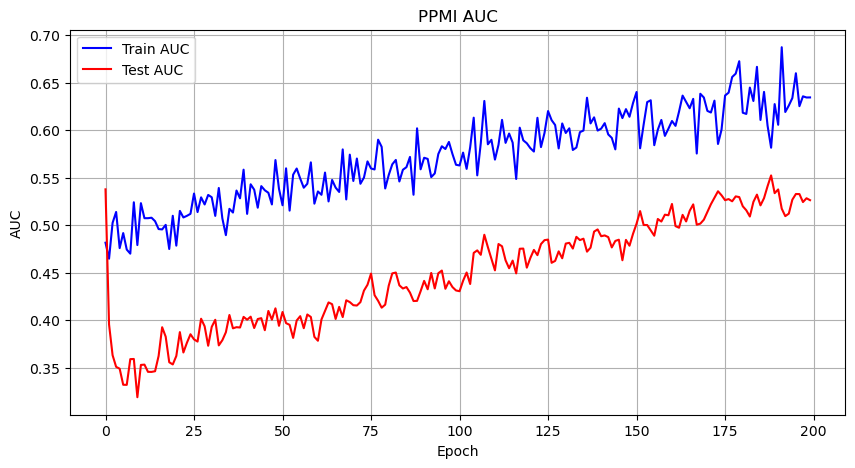

In [58]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)), test_aucs, label="Test AUC", color="red")
plt.title("PPMI AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()

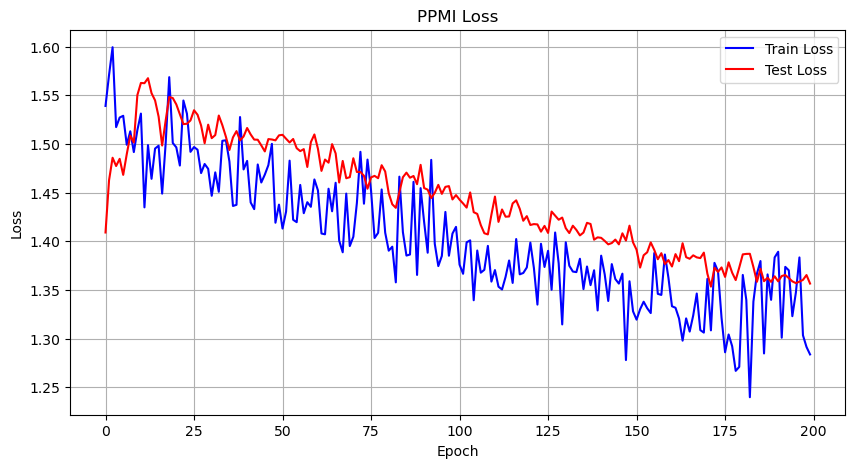

In [59]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("PPMI Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()